<a href="https://www.kaggle.com/code/omborse771924/titanic-passenger-survival-prediction-accuracy-98?scriptVersionId=346852236" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arjunsinghgangwar/titanic-survival-prediction-dataset/Titanic-Dataset.csv


## Loadin Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/arjunsinghgangwar/titanic-survival-prediction-dataset/Titanic-Dataset.csv')

In [3]:
df.head()

,Name,Sex,Age,SibSp,Parch,Embarked,Ticket,Fare,Cabin,PassengerId,Pclass,Survived
0,"Braund, Mr. Owen Harris",male,22.0,1,0,S,A/5 21171,7.2500,NaN,1,3,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C,PC 17599,71.2833,C85,2,1,1
2,"Heikkinen, Miss. Laina",female,26.0,0,0,S,STON/O2. 3101282,7.9250,NaN,3,3,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,S,113803,53.1000,C123,4,1,1
4,"Allen, Mr. William Henry",male,35.0,0,0,S,373450,8.0500,NaN,5,3,0


In [4]:
df.tail()

,Name,Sex,Age,SibSp,Parch,Embarked,Ticket,Fare,Cabin,PassengerId,Pclass,Survived
886,"Montvila, Rev. Juozas",male,27.0,0,0,S,211536,13.00,NaN,887,2,0
887,"Graham, Miss. Margaret Edith",female,19.0,0,0,S,112053,30.00,B42,888,1,1
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,S,W./C. 6607,23.45,NaN,889,3,0
889,"Behr, Mr. Karl Howell",male,26.0,0,0,C,111369,30.00,C148,890,1,1
890,"Dooley, Mr. Patrick",male,32.0,0,0,Q,370376,7.75,NaN,891,3,0


In [5]:
df.info

<bound method DataFrame.info of                                                   Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch Embarked

In [6]:
df.describe

<bound method NDFrame.describe of                                                   Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch Embark

In [7]:
df.isnull()

,Name,Sex,Age,SibSp,Parch,Embarked,Ticket,Fare,Cabin,PassengerId,Pclass,Survived
0,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,True,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Embarked         2
Ticket           0
Fare             0
Cabin          687
PassengerId      0
Pclass           0
Survived         0
dtype: int64

In [9]:
# Check null values before handling
print("Null values before handling:")
print(df.isnull().sum())

# -----------------------------
# 1. Handle Age
# -----------------------------
df["Age"] = df["Age"].fillna(df["Age"].median())

# -----------------------------
# 2. Handle Embarked
# -----------------------------
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# -----------------------------
# 3. Handle Cabin
# -----------------------------
df["Cabin"] = df["Cabin"].fillna("Unknown")

# -----------------------------
# Check null values after handling
# -----------------------------
print("\nNull values after handling:")
print(df.isnull().sum())

Null values before handling:
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Embarked         2
Ticket           0
Fare             0
Cabin          687
PassengerId      0
Pclass           0
Survived         0
dtype: int64

Null values after handling:
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Embarked       0
Ticket         0
Fare           0
Cabin          0
PassengerId    0
Pclass         0
Survived       0
dtype: int64


In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked', 'Ticket', 'Fare',
       'Cabin', 'PassengerId', 'Pclass', 'Survived'],
      dtype='object')

## EDA

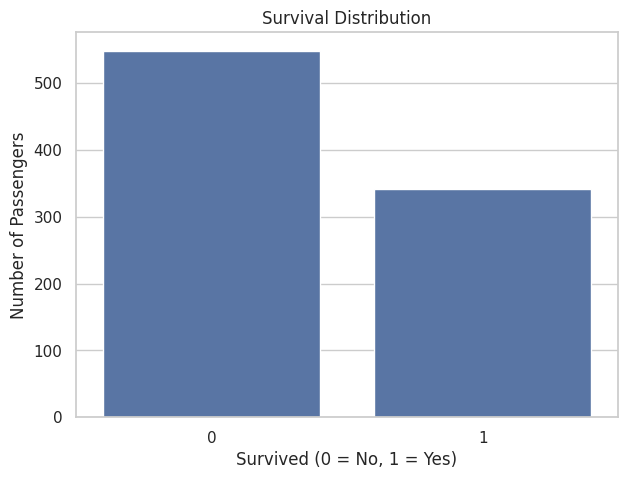

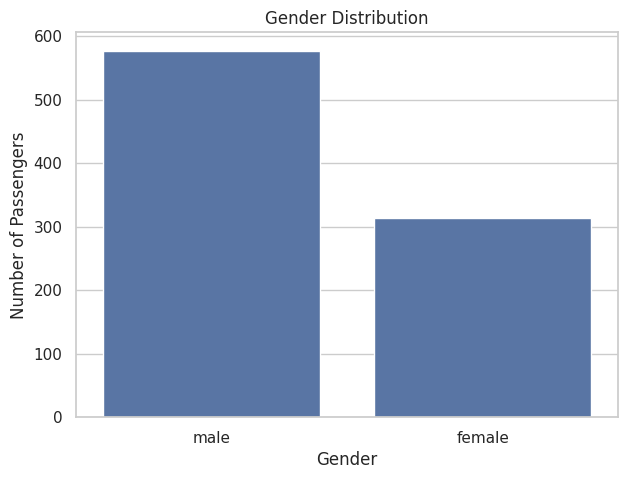

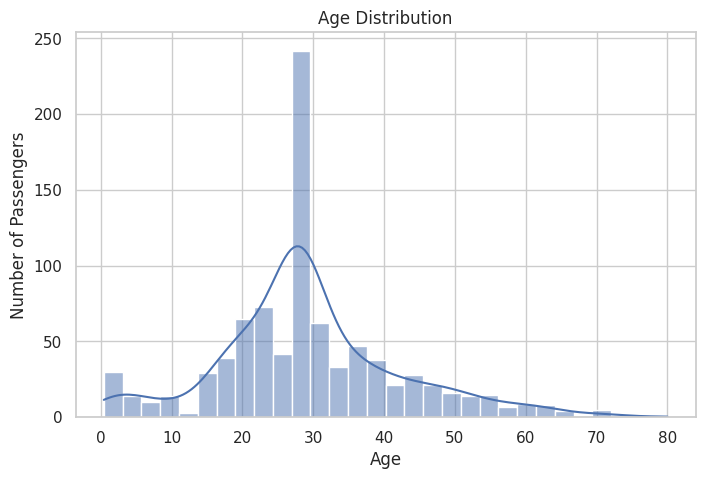

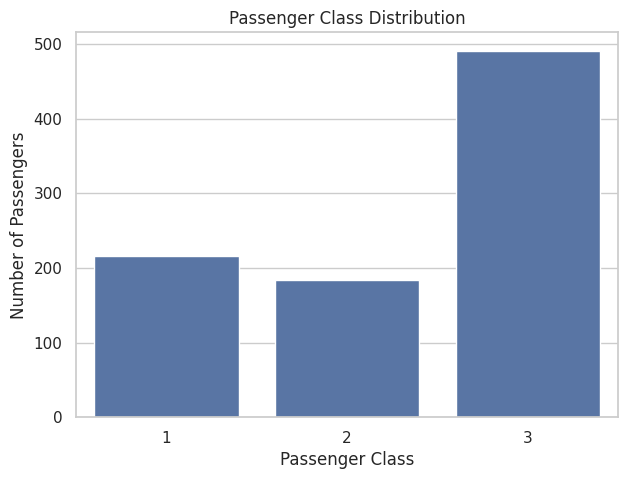

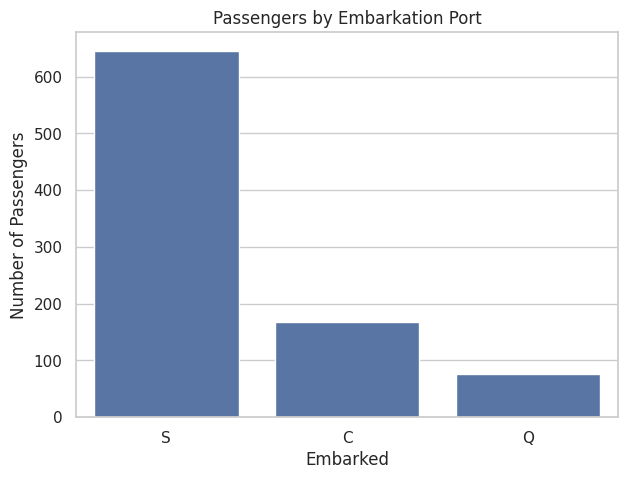

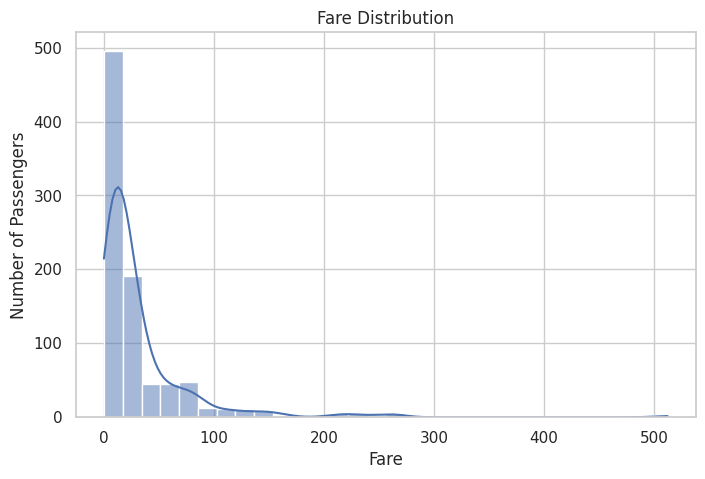

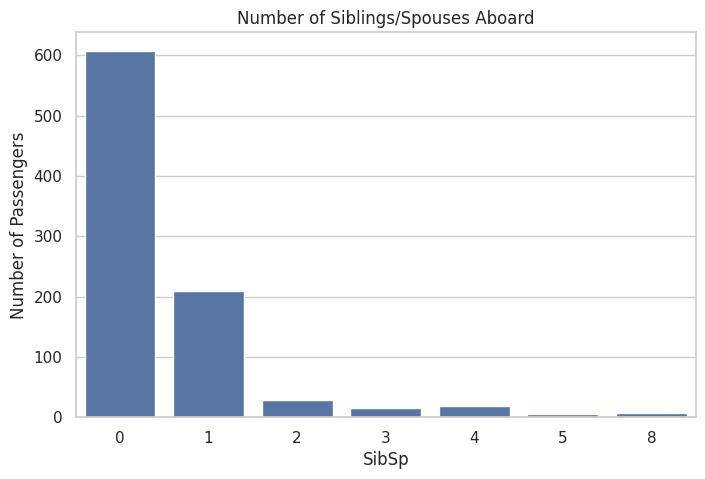

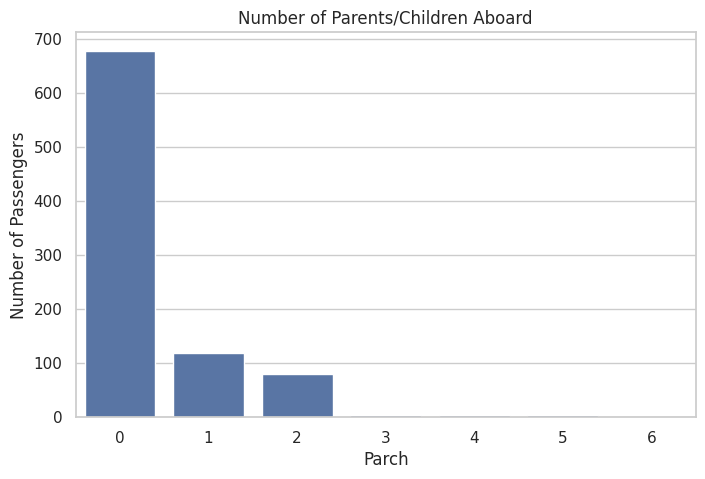

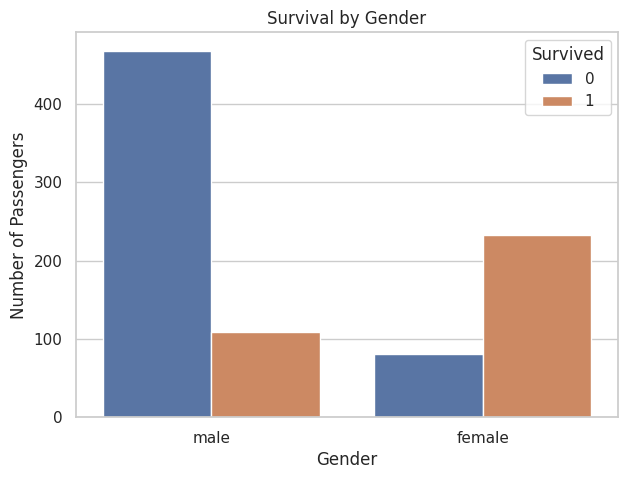

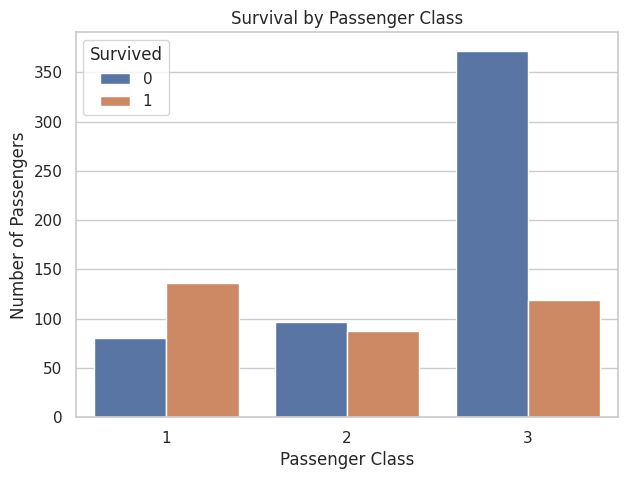

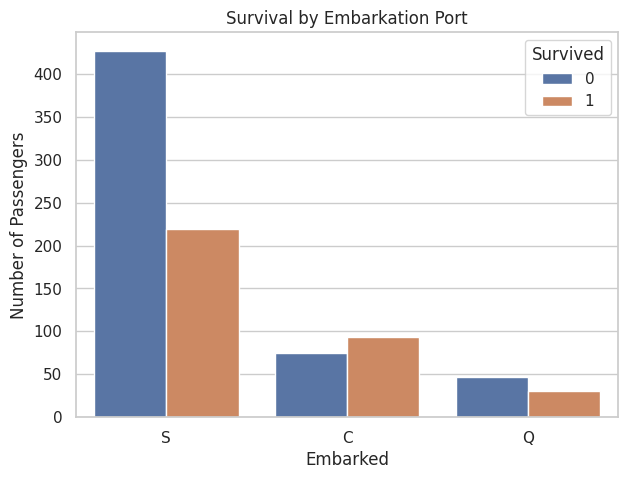

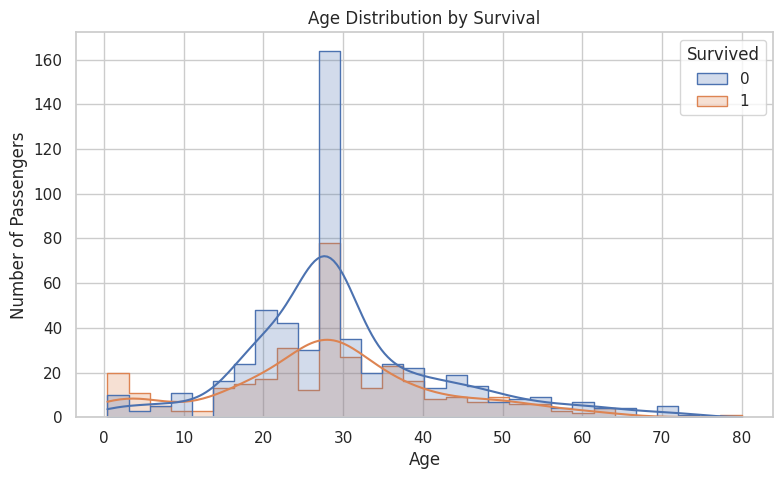

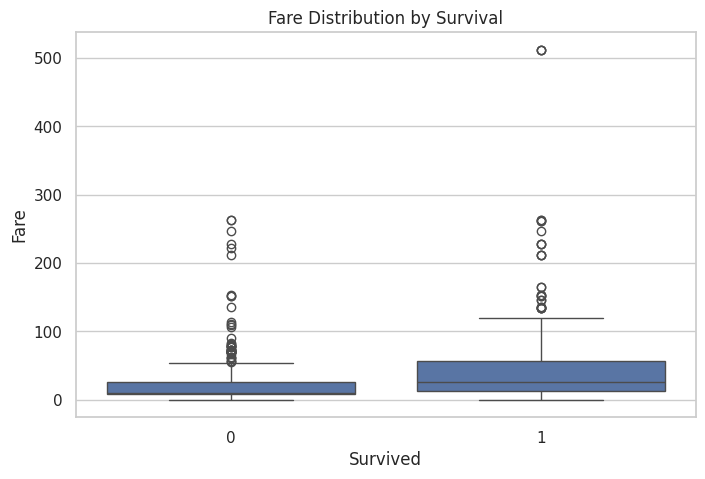

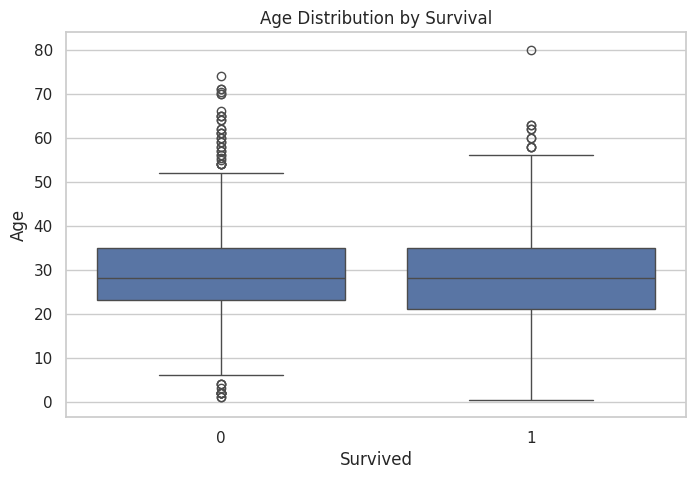

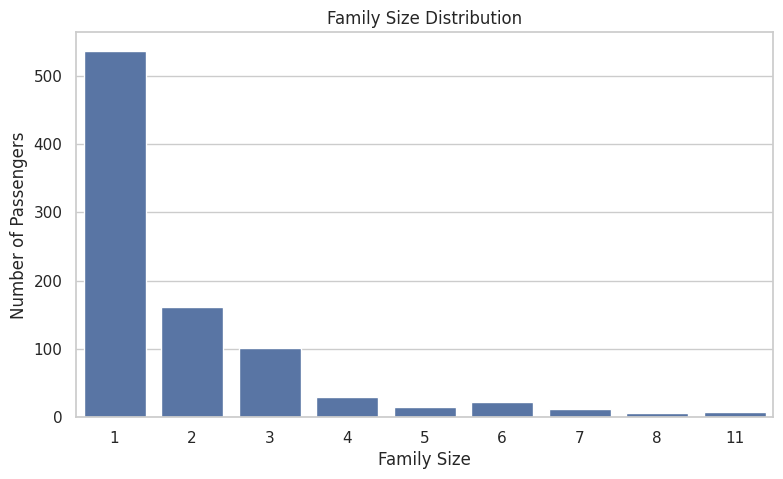

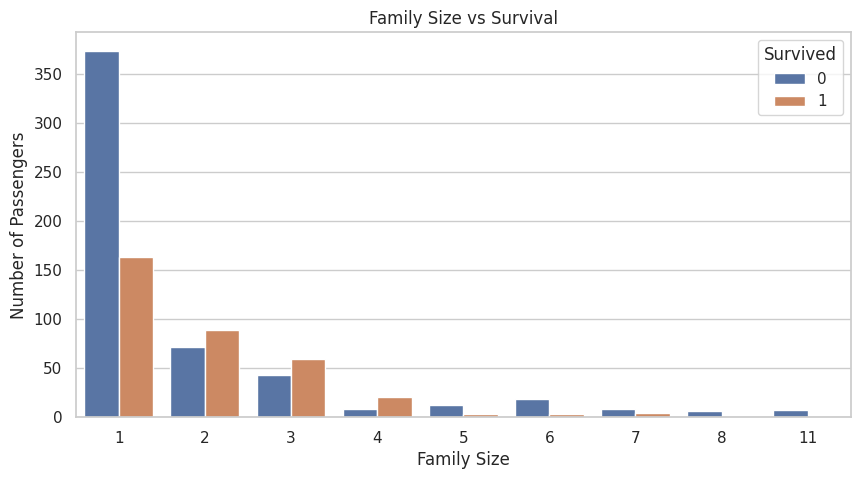

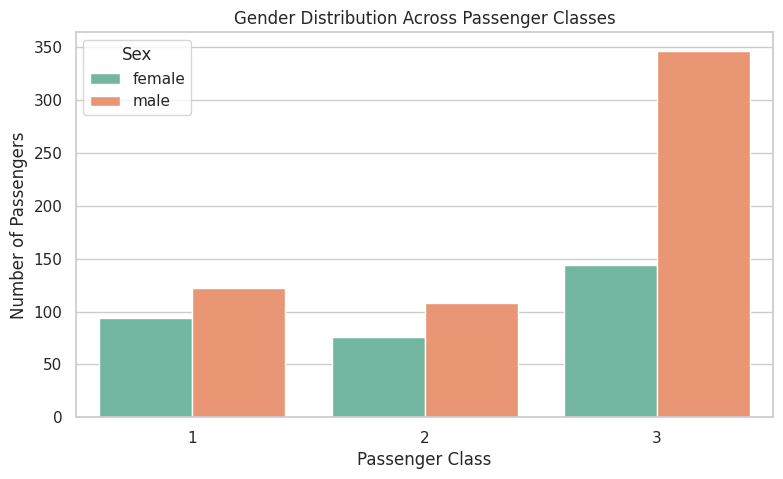

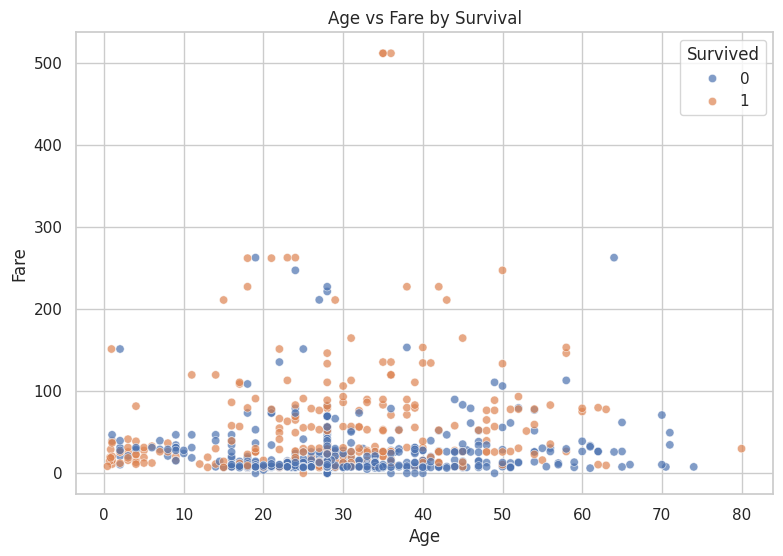

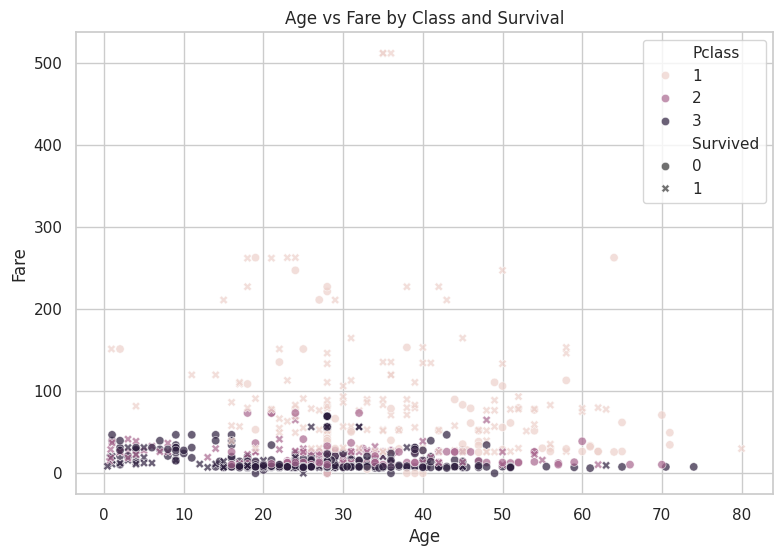

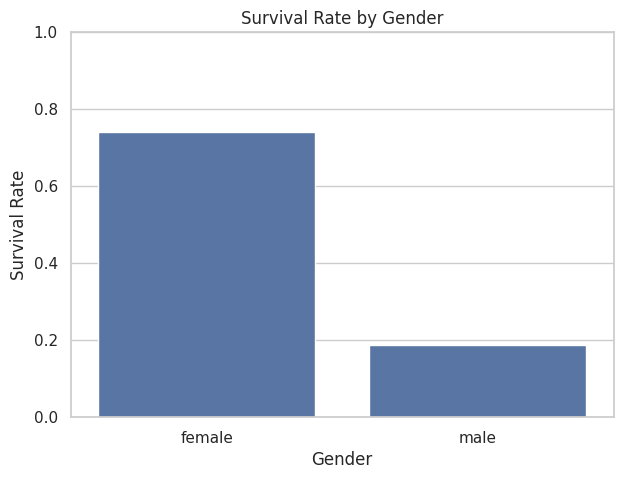

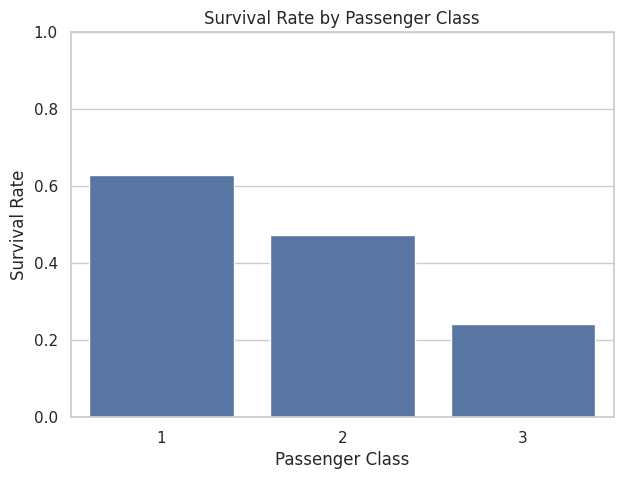

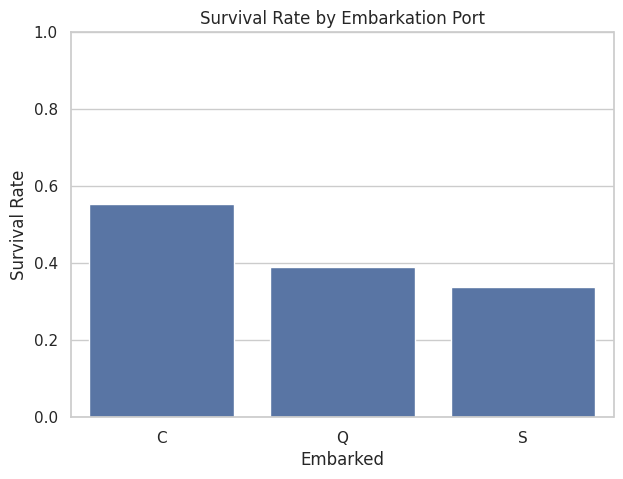

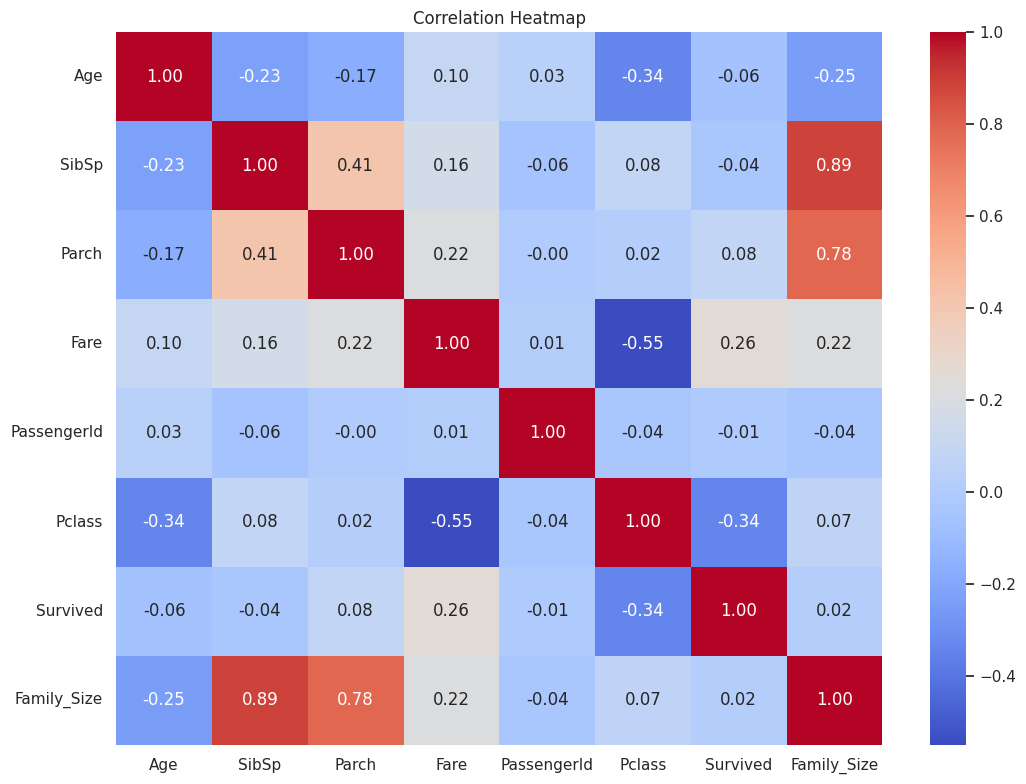


Correlation with Survived:
Survived       1.000000
Fare           0.257307
Parch          0.081629
Family_Size    0.016639
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481
Name: Survived, dtype: float64


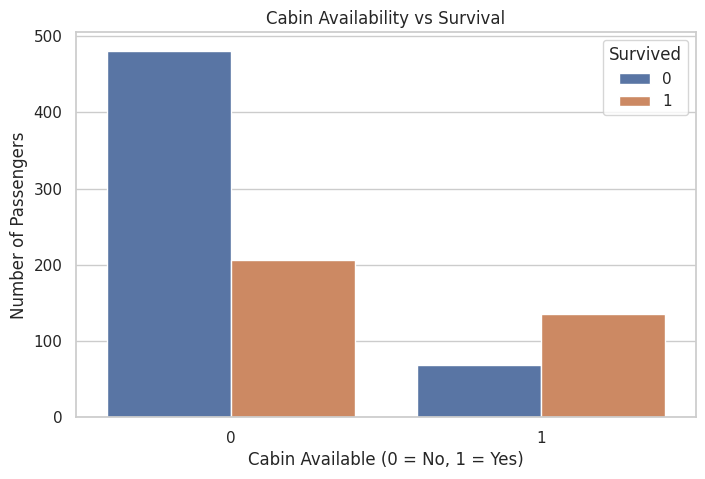

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# SETUP
# =========================================================

sns.set_theme(style="whitegrid")

# Remove duplicate rows if any
df = df.drop_duplicates().reset_index(drop=True)

# =========================================================
# 1. SURVIVAL DISTRIBUTION
# =========================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 2. GENDER DISTRIBUTION
# =========================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 3. AGE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 4. PASSENGER CLASS DISTRIBUTION
# =========================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Pclass")
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 5. EMBARKED DISTRIBUTION
# =========================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Embarked")
plt.title("Passengers by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 6. FARE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 7. SIBSP DISTRIBUTION
# =========================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="SibSp")
plt.title("Number of Siblings/Spouses Aboard")
plt.xlabel("SibSp")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 8. PARCH DISTRIBUTION
# =========================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Parch")
plt.title("Number of Parents/Children Aboard")
plt.xlabel("Parch")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 9. SURVIVAL BY GENDER
# =========================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 10. SURVIVAL BY PASSENGER CLASS
# =========================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 11. SURVIVAL BY EMBARKATION PORT
# =========================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Embarked", hue="Survived")
plt.title("Survival by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 12. SURVIVAL BY AGE
# =========================================================

plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step"
)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 13. FARE BY SURVIVAL
# =========================================================

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()


# =========================================================
# 14. AGE BY SURVIVAL
# =========================================================

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()


# =========================================================
# 15. FAMILY SIZE
# =========================================================

# Create family size
df["Family_Size"] = df["SibSp"] + df["Parch"] + 1

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Family_Size")
plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 16. FAMILY SIZE VS SURVIVAL
# =========================================================

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Family_Size", hue="Survived")
plt.title("Family Size vs Survival")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 17. GENDER + CLASS VS SURVIVAL
# =========================================================

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="Pclass",
    hue="Sex",
    palette="Set2"
)
plt.title("Gender Distribution Across Passenger Classes")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()


# =========================================================
# 18. AGE VS FARE
# =========================================================

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived",
    alpha=0.7
)
plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


# =========================================================
# 19. AGE VS FARE WITH CLASS
# =========================================================

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Pclass",
    style="Survived",
    alpha=0.7
)
plt.title("Age vs Fare by Class and Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


# =========================================================
# 20. SURVIVAL RATE BY GENDER
# =========================================================

survival_gender = df.groupby("Sex")["Survived"].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(
    data=survival_gender,
    x="Sex",
    y="Survived"
)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


# =========================================================
# 21. SURVIVAL RATE BY CLASS
# =========================================================

survival_class = df.groupby("Pclass")["Survived"].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(
    data=survival_class,
    x="Pclass",
    y="Survived"
)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


# =========================================================
# 22. SURVIVAL RATE BY EMBARKED
# =========================================================

survival_embarked = df.groupby("Embarked")["Survived"].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(
    data=survival_embarked,
    x="Embarked",
    y="Survived"
)
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


# =========================================================
# 23. CORRELATION HEATMAP
# =========================================================

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(11, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# =========================================================
# 24. CORRELATION WITH SURVIVED
# =========================================================

correlation = numeric_df.corr()["Survived"].sort_values(
    ascending=False
)

print("\nCorrelation with Survived:")
print(correlation)


# =========================================================
# 25. CABIN AVAILABILITY VS SURVIVAL
# =========================================================

df["Cabin_Available"] = (
    df["Cabin"] != "Unknown"
).astype(int)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Cabin_Available",
    hue="Survived"
)
plt.title("Cabin Availability vs Survival")
plt.xlabel("Cabin Available (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

## Features Engineering

Original Shape: (891, 14)
Duplicate rows: 0
Shape after removing duplicates: (891, 14)

Engineered Features:
                                                Name   Age  Family_Size  \
0                            Braund, Mr. Owen Harris  22.0            2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0            2   
2                             Heikkinen, Miss. Laina  26.0            1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0            2   
4                           Allen, Mr. William Henry  35.0            1   

   Is_Alone Family_Size_Category  Cabin_Available Title  Fare_Per_Person  \
0         0                Small                0    Mr          3.62500   
1         0                Small                1   Mrs         35.64165   
2         1                Alone                0  Miss          7.92500   
3         0                Small                1   Mrs         26.55000   
4         1                Alone                0    Mr     

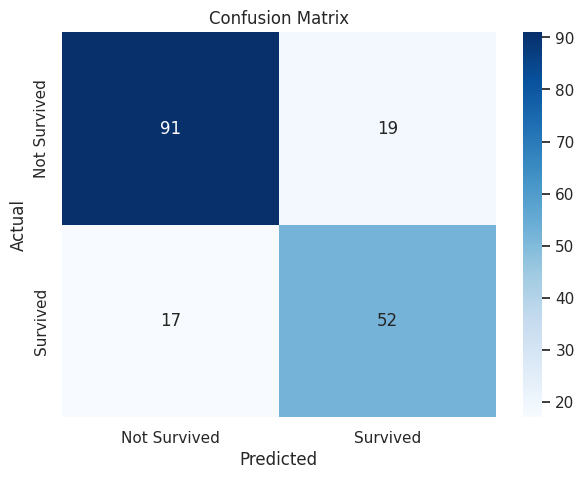


         TOP 20 IMPORTANT FEATURES
                                     Feature  Importance
0                               numeric__Age    0.150521
8                   numeric__Fare_Per_Person    0.140207
3                              numeric__Fare    0.135783
20                     categorical__Title_Mr    0.098774
9                    categorical__Sex_female    0.098493
10                     categorical__Sex_male    0.069325
4                            numeric__Pclass    0.041884
6                   numeric__Cabin_Available    0.040455
5                       numeric__Family_Size    0.030597
19                   categorical__Title_Miss    0.021475
1                             numeric__SibSp    0.019578
21                    categorical__Title_Mrs    0.018177
17   categorical__Family_Size_Category_Small    0.018071
2                             numeric__Parch    0.014654
13                   categorical__Embarked_S    0.014045
27        categorical__Age_Group_Young Adult    0.01

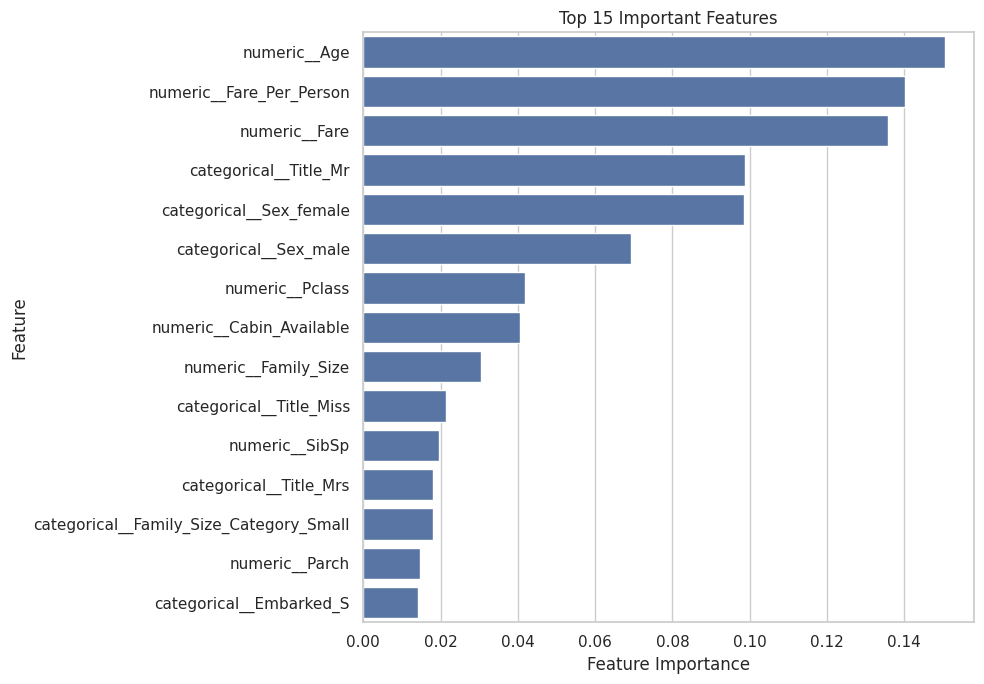

In [14]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. COPY DATA
# =========================================================

data = df.copy()

print("Original Shape:", data.shape)


# =========================================================
# 2. REMOVE DUPLICATES
# =========================================================

print("Duplicate rows:", data.duplicated().sum())

data = data.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", data.shape)


# =========================================================
# 3. HANDLE NULL VALUES
# =========================================================

# Age -> Median
data["Age"] = data["Age"].fillna(data["Age"].median())

# Embarked -> Mode
data["Embarked"] = data["Embarked"].fillna(
    data["Embarked"].mode()[0]
)

# Cabin -> Unknown
data["Cabin"] = data["Cabin"].fillna("Unknown")


# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================

# ---------------------------------------------------------
# Family Size
# SibSp = siblings/spouses
# Parch = parents/children
# ---------------------------------------------------------

data["Family_Size"] = (
    data["SibSp"] +
    data["Parch"] +
    1
)


# ---------------------------------------------------------
# Is Alone
# ---------------------------------------------------------

data["Is_Alone"] = (
    data["Family_Size"] == 1
).astype(int)


# ---------------------------------------------------------
# Family Size Category
# ---------------------------------------------------------

data["Family_Size_Category"] = pd.cut(
    data["Family_Size"],
    bins=[0, 1, 4, 7, np.inf],
    labels=[
        "Alone",
        "Small",
        "Medium",
        "Large"
    ]
)


# ---------------------------------------------------------
# Cabin Available
# ---------------------------------------------------------

data["Cabin_Available"] = (
    data["Cabin"] != "Unknown"
).astype(int)


# ---------------------------------------------------------
# Title Extraction
# Example: Mr, Miss, Mrs, Master
# ---------------------------------------------------------

data["Title"] = (
    data["Name"]
    .str.extract(r",\s*([^.]*)\.")[0]
    .str.strip()
)


# Group rare titles
title_counts = data["Title"].value_counts()

rare_titles = title_counts[
    title_counts < 10
].index

data["Title"] = data["Title"].replace(
    rare_titles,
    "Rare"
)


# ---------------------------------------------------------
# Fare Per Person
# ---------------------------------------------------------

data["Fare_Per_Person"] = (
    data["Fare"] /
    data["Family_Size"]
)


# ---------------------------------------------------------
# Age Groups
# ---------------------------------------------------------

data["Age_Group"] = pd.cut(
    data["Age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=[
        "Child",
        "Teenager",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)


# =========================================================
# 5. DISPLAY ENGINEERED FEATURES
# =========================================================

print("\nEngineered Features:")

print(
    data[
        [
            "Name",
            "Age",
            "Family_Size",
            "Is_Alone",
            "Family_Size_Category",
            "Cabin_Available",
            "Title",
            "Fare_Per_Person",
            "Age_Group"
        ]
    ].head()
)


# =========================================================
# 6. TARGET VARIABLE
# =========================================================

target = "Survived"

X = data.drop(
    columns=[target]
)

y = data[target]


# =========================================================
# 7. DROP UNNECESSARY / HIGH-CARDINALITY COLUMNS
# =========================================================

X = X.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ],
    errors="ignore"
)


# =========================================================
# 8. IDENTIFY NUMERIC & CATEGORICAL FEATURES
# =========================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# =========================================================
# 9. PREPROCESSING
# =========================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


# =========================================================
# 10. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining data:", X_train.shape)
print("Testing data :", X_test.shape)


# =========================================================
# 11. RANDOM FOREST CLASSIFIER
# =========================================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])


# =========================================================
# 12. TRAIN MODEL
# =========================================================

print("\nTraining model...")

model.fit(
    X_train,
    y_train
)

print("Training completed!")


# =========================================================
# 13. PREDICTIONS
# =========================================================

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)


# =========================================================
# 14. ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)


print("\n========================================")
print("             MODEL ACCURACY")
print("========================================")

print(
    "Training Accuracy:",
    round(train_accuracy * 100, 2),
    "%"
)

print(
    "Testing Accuracy :",
    round(test_accuracy * 100, 2),
    "%"
)


# =========================================================
# 15. CLASSIFICATION REPORT
# =========================================================

print("\n========================================")
print("         CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y_test,
        y_test_pred
    )
)


# =========================================================
# 16. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("\n========================================")
print("            CONFUSION MATRIX")
print("========================================")

print(cm)


# =========================================================
# 17. CONFUSION MATRIX VISUALIZATION
# =========================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================================================
# 18. FEATURE IMPORTANCE
# =========================================================

feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    model
    .named_steps["classifier"]
    .feature_importances_
)


feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


# =========================================================
# 19. TOP 20 FEATURES
# =========================================================

print("\n========================================")
print("         TOP 20 IMPORTANT FEATURES")
print("========================================")

print(
    feature_importance.head(20)
)


# =========================================================
# 20. FEATURE IMPORTANCE VISUALIZATION
# =========================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Thanks.........Please Upvote